# TT-08 — XGBoost: Phát hiện gian lận thẻ tín dụng theo thời gian thực

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
RANDOM_STATE = 42
COST_CHAN_NHAM = 200_000
PRECISION_TARGET = 0.90

DATA_PATH = r"../dataset/creditcard.csv"

## 1. Nạp dữ liệu, xác nhận tỉ lệ lệch

In [25]:
df = pd.read_csv(DATA_PATH)

fraud_rate = df["Class"].mean()
print(f"Tổng giao dịch: {len(df):,} | Tỉ lệ gian lận: {fraud_rate:.4%} ({df['Class'].sum()} ca)")
df.head()

Tổng giao dịch: 284,807 | Tỉ lệ gian lận: 0.1727% (492 ca)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Feature engineering: Time -> Hour, scale Amount

In [26]:
# Time (giây từ giao dịch đầu tiên) -> giờ trong ngày [0-23]
df["Hour"] = (df["Time"] // 3600) % 24
# Amount: log1p để giảm lệch phải, rồi StandardScaler
df["Amount_log"] = np.log1p(df["Amount"])
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount_log"]])
df[["Time", "Hour", "Amount", "Amount_log", "Amount_scaled"]].head()

,Time,Hour,Amount,Amount_log,Amount_scaled
0,0.0,0.0,149.62,5.014760,1.124303
1,0.0,0.0,2.69,1.305626,-1.114639
2,1.0,0.0,378.66,5.939276,1.682368
3,1.0,0.0,123.50,4.824306,1.009339
4,2.0,0.0,69.99,4.262539,0.670241


## 3. EDA — tỉ lệ gian lận theo giờ, phân phối Amount theo lớp

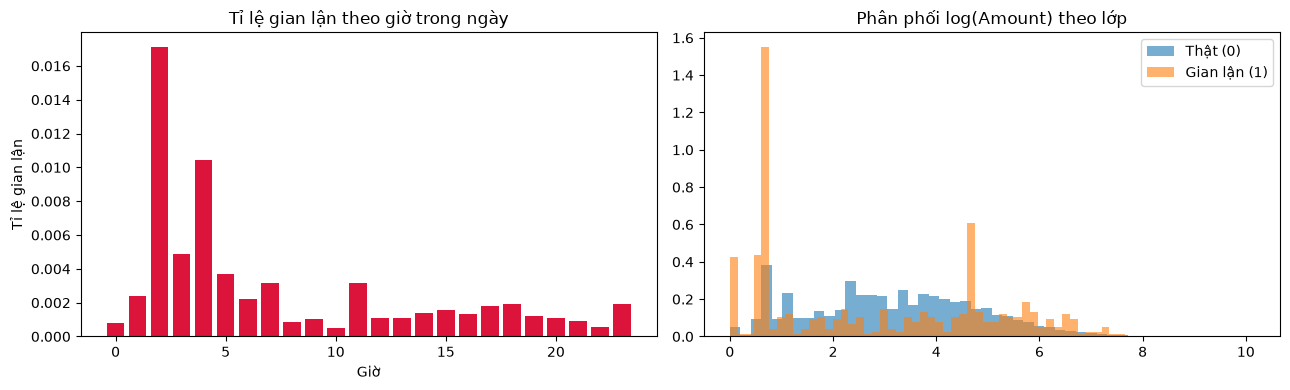

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fraud_by_hour = df.groupby("Hour")["Class"].mean()
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color="crimson")
axes[0].set_title("Tỉ lệ gian lận theo giờ trong ngày")
axes[0].set_xlabel("Giờ"); axes[0].set_ylabel("Tỉ lệ gian lận")

axes[1].hist(df.loc[df.Class == 0, "Amount_log"], bins=50, alpha=0.6, label="Thật (0)", density=True)
axes[1].hist(df.loc[df.Class == 1, "Amount_log"], bins=50, alpha=0.6, label="Gian lận (1)", density=True)
axes[1].set_title("Phân phối log(Amount) theo lớp")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/eda_overview.png", dpi=120)
plt.show()

## 4. Chia dữ liệu THEO THỜI GIAN (không shuffle)

In [28]:
df_sorted = df.sort_values("Time").reset_index(drop=True)
n = len(df_sorted)
i_train = int(n * 0.70)
i_val = int(n * 0.85)

feature_cols = [c for c in df_sorted.columns if c.startswith("V")] + ["Hour", "Amount_scaled"]

train, val, test = df_sorted.iloc[:i_train], df_sorted.iloc[i_train:i_val], df_sorted.iloc[i_val:]
print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

X_train, y_train = train[feature_cols], train["Class"]
X_val, y_val = val[feature_cols], val["Class"]
X_test, y_test = test[feature_cols], test["Class"]

Train: 199,364 | Val: 42,721 | Test: 42,722


## 5. Baseline: DummyClassifier

In [29]:
results = {}

def evaluate(name, proba):
    pr_auc = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    results[name] = {"pr_auc": pr_auc, "roc_auc": roc_auc, "proba": proba}
    print(f"{name:22s} | PR-AUC = {pr_auc:.4f} | ROC-AUC = {roc_auc:.4f}")

dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
evaluate("Dummy (baseline)", dummy.predict_proba(X_test)[:, 1])

Dummy (baseline)       | PR-AUC = 0.0012 | ROC-AUC = 0.4991


## 6. Logistic Regression (baseline mạnh)

In [30]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
evaluate("Logistic Regression", logreg.predict_proba(X_test)[:, 1])

Logistic Regression    | PR-AUC = 0.6952 | ROC-AUC = 0.9778


## 7. XGBoost — model chính

In [31]:
ty_le = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {ty_le:.1f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ty_le,
    reg_lambda=1.0, reg_alpha=0.1,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
evaluate("XGBoost", xgb_model.predict_proba(X_test)[:, 1])

scale_pos_weight = 518.2
[0]	validation_0-aucpr:0.27953
[100]	validation_0-aucpr:0.85010
[200]	validation_0-aucpr:0.85164
[214]	validation_0-aucpr:0.85062
XGBoost                | PR-AUC = 0.7571 | ROC-AUC = 0.9831


## 8.So sánh ROC-AUC vs PR-AUC 

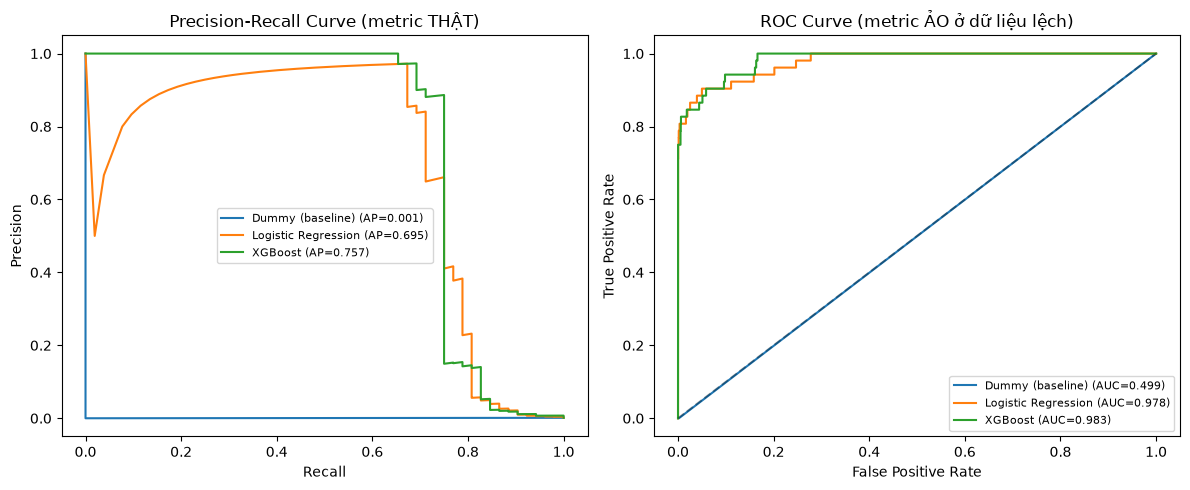

XGBoost: ROC-AUC = 0.9831 | PR-AUC = 0.7571


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    axes[0].plot(rec, prec, label=f"{name} (AP={r['pr_auc']:.3f})")
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (metric THẬT)")
axes[0].legend(fontsize=8)

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (metric ẢO ở dữ liệu lệch)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../reports/pr_vs_roc.png", dpi=120)
plt.show()

xgb_res = results["XGBoost"]
print(f"XGBoost: ROC-AUC = {xgb_res['roc_auc']:.4f} | PR-AUC = {xgb_res['pr_auc']:.4f}")

## 9-10. Chọn ngưỡng theo Precision >= 0.90 và theo chi phí

Ngưỡng để Precision >= 0.9: 0.9902864098548889 (Recall = 0.712)
Ngưỡng tối ưu lợi nhuận = 0.99 | Tổng chi phí = 802,621đ


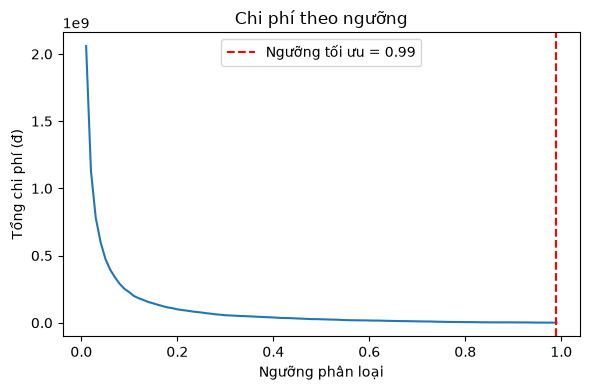

In [33]:
proba = results["XGBoost"]["proba"]
prec, rec, thr = precision_recall_curve(y_test, proba)

idx = np.argmax(prec[:-1] >= PRECISION_TARGET)
thr_precision = thr[idx] if prec[idx] >= PRECISION_TARGET else None
print(f"Ngưỡng để Precision >= {PRECISION_TARGET}: {thr_precision} (Recall = {rec[idx]:.3f})")

amounts = test["Amount"].values

thresholds_grid = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds_grid:
    pred = (proba >= t).astype(int)
    fp_mask = (pred == 1) & (y_test.values == 0)
    fn_mask = (pred == 0) & (y_test.values == 1)
    cost = fp_mask.sum() * COST_CHAN_NHAM + amounts[fn_mask].sum()
    costs.append(cost)
costs = np.array(costs)
best_idx = costs.argmin()
best_threshold = thresholds_grid[best_idx]

print(f"Ngưỡng tối ưu lợi nhuận = {best_threshold:.2f} | Tổng chi phí = {costs[best_idx]:,.0f}đ")

plt.figure(figsize=(6, 4))
plt.plot(thresholds_grid, costs)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Ngưỡng tối ưu = {best_threshold:.2f}")
plt.xlabel("Ngưỡng phân loại"); plt.ylabel("Tổng chi phí (đ)")
plt.title("Chi phí theo ngưỡng")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/chi_phi_theo_nguong.png", dpi=120)
plt.show()

## 11. Đo thời gian dự đoán 1 giao dịch (yêu cầu < 100ms)

In [34]:
sample = X_test.iloc[[0]]
for _ in range(5):
    xgb_model.predict_proba(sample)

times = []
for _ in range(200):
    t0 = time.perf_counter()
    xgb_model.predict_proba(sample)
    times.append((time.perf_counter() - t0) * 1000)

p50, p99 = np.percentile(times, [50, 99])
print(f"Độ trễ: p50 = {p50:.2f} ms | p99 = {p99:.2f} ms -> {'ĐẠT' if p99 < 100 else 'KHÔNG ĐẠT'}")

Độ trễ: p50 = 1.64 ms | p99 = 3.34 ms -> ĐẠT


## 12. So sánh với Random Forest và LightGBM

In [35]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                             n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
evaluate("Random Forest", rf.predict_proba(X_test)[:, 1])

lgb_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=4,
                            scale_pos_weight=ty_le, random_state=RANDOM_STATE, verbose=-1)
lgb_model.fit(X_train, y_train)
evaluate("LightGBM", lgb_model.predict_proba(X_test)[:, 1])

Random Forest          | PR-AUC = 0.7762 | ROC-AUC = 0.9805
LightGBM               | PR-AUC = 0.0145 | ROC-AUC = 0.8596


## Feature Importance

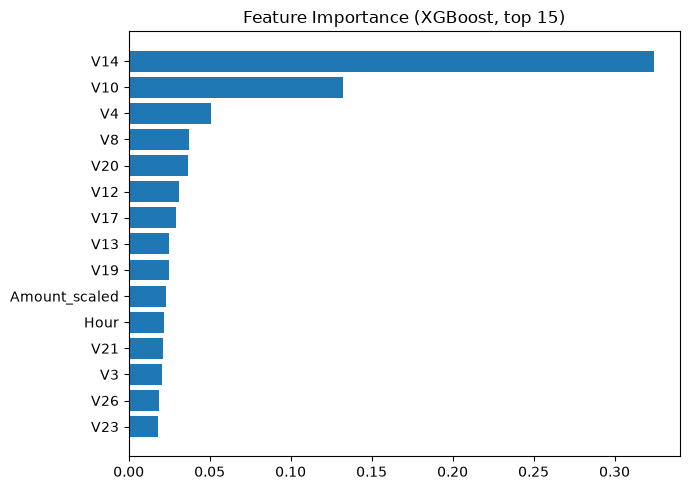

In [36]:
importances = xgb_model.feature_importances_
order = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(7, 5))
plt.barh([feature_cols[i] for i in order][::-1], importances[order][::-1])
plt.title("Feature Importance (XGBoost, top 15)")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=120)
plt.show()

## Lưu model

In [37]:
xgb_model.save_model("../models/xgb_fraud.json")
print("Đã lưu model tại models/xgb_fraud.json")

Đã lưu model tại models/xgb_fraud.json
